# Part 2b — Wind Reliability Analysis

**Objective:** As a grid planner, recommend how many MW of wind power the UK can reliably count on to meet electricity demand.

**Dataset:**
- `actuals.csv` — Half-hourly actual wind generation (FUELHH, fuelType=WIND), January 2024

**Questions we want to answer:**
1. What are the key percentiles of generation? (What level are we above X% of the time?)
2. When generation drops low, how long does it stay low?
3. Does time of day affect how much wind we can count on?
4. What was the worst-case stretch in January?
5. What MW number should we recommend, and why?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

## 1. Load & Inspect

In [2]:
actuals = pd.read_csv('actuals.csv', parse_dates=['startTime'])
actuals = actuals.sort_values('startTime').reset_index(drop=True)

print(f'Rows: {len(actuals)}')
print(f'Date range: {actuals["startTime"].min()} to {actuals["startTime"].max()}')
print()
print(actuals['generation'].describe())

Rows: 1489
Date range: 2023-12-31 23:30:00+00:00 to 2024-01-31 23:30:00+00:00

count     1489.000000
mean      9848.818670
std       3674.784894
min          0.000000
25%       6733.000000
50%       9883.000000
75%      13105.000000
max      16662.000000
Name: generation, dtype: float64


## 2. Observe the Generation Pattern

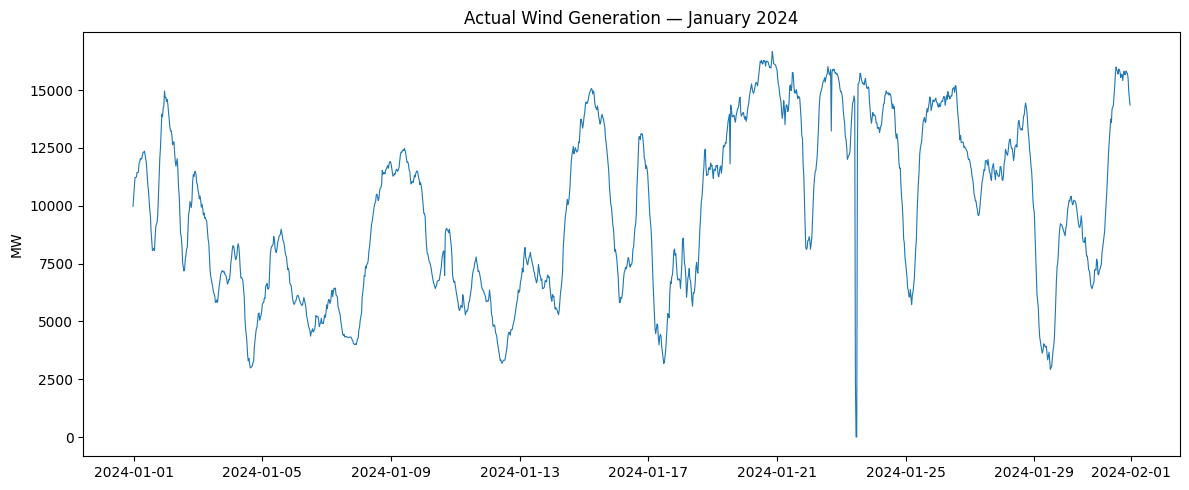

In [3]:
plt.plot(actuals['startTime'], actuals['generation'], linewidth=0.8)
plt.ylabel('MW')
plt.title('Actual Wind Generation — January 2024')
plt.tight_layout()
plt.show()

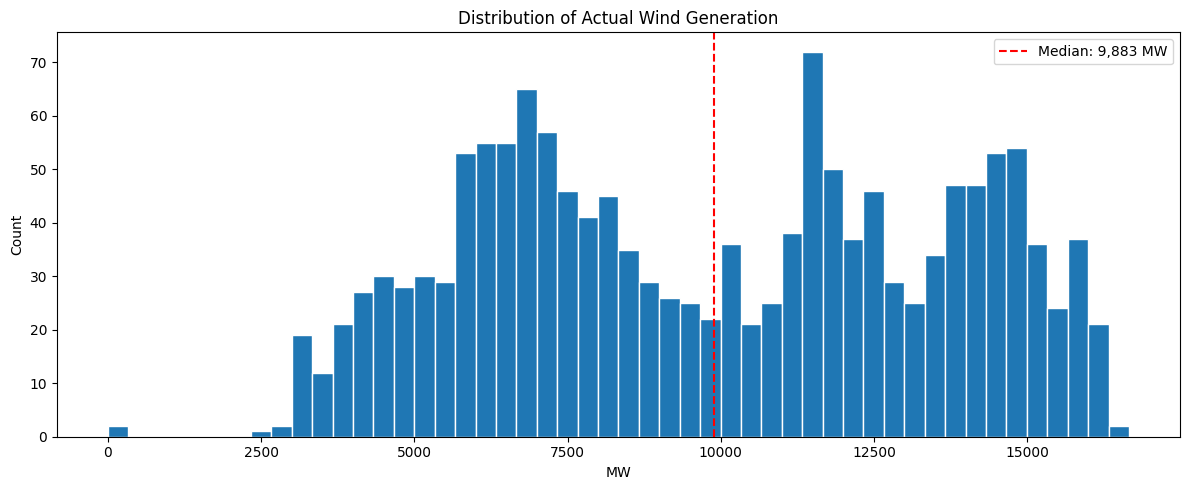

In [4]:
plt.hist(actuals['generation'], bins=50, edgecolor='white')
plt.xlabel('MW')
plt.ylabel('Count')
plt.title('Distribution of Actual Wind Generation')
plt.axvline(actuals['generation'].median(), color='red', linestyle='--',
            label=f'Median: {actuals["generation"].median():,.0f} MW')
plt.legend()
plt.tight_layout()
plt.show()

---

## 3. Question 1 — Key Percentiles

If we pick a number X, how often was generation above X?

In [5]:
percentiles = [1, 5, 10, 25, 50, 75, 90, 95, 99]
print('Generation Percentiles:')
print()
for p in percentiles:
    val = actuals['generation'].quantile(p / 100)
    print(f'  P{p:<3d} = {val:>8,.0f} MW  →  generation was above this {100-p}% of the time')

Generation Percentiles:

  P1   =    3,234 MW  →  generation was above this 99% of the time
  P5   =    4,301 MW  →  generation was above this 95% of the time
  P10  =    5,089 MW  →  generation was above this 90% of the time
  P25  =    6,733 MW  →  generation was above this 75% of the time
  P50  =    9,883 MW  →  generation was above this 50% of the time
  P75  =   13,105 MW  →  generation was above this 25% of the time
  P90  =   14,809 MW  →  generation was above this 10% of the time
  P95  =   15,424 MW  →  generation was above this 5% of the time
  P99  =   16,130 MW  →  generation was above this 1% of the time


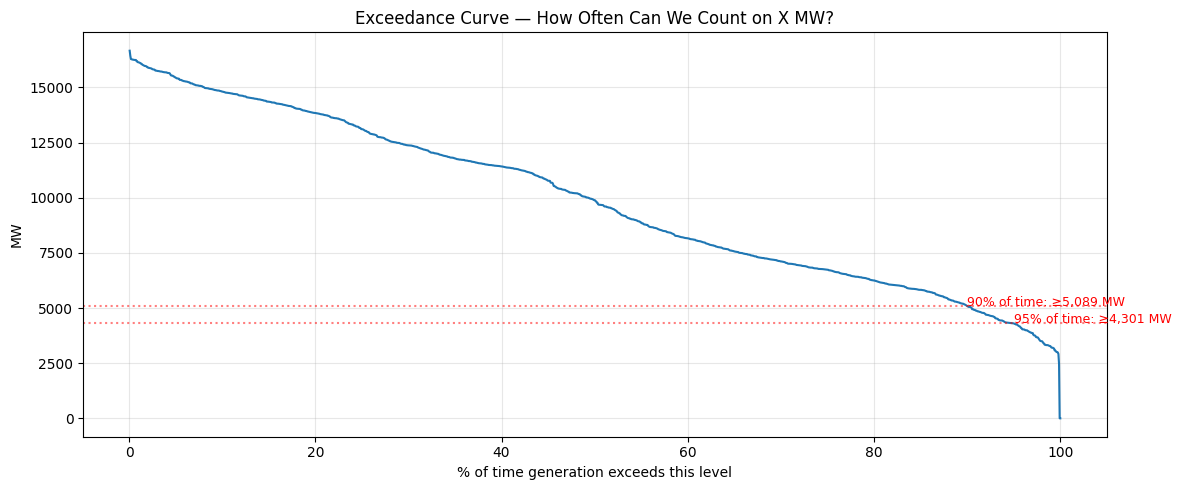

In [6]:
# Exceedance curve — visual version of the above
sorted_gen = np.sort(actuals['generation'])[::-1]
exceedance_pct = np.arange(1, len(sorted_gen) + 1) / len(sorted_gen) * 100

plt.plot(exceedance_pct, sorted_gen, linewidth=1.5)
plt.xlabel('% of time generation exceeds this level')
plt.ylabel('MW')
plt.title('Exceedance Curve — How Often Can We Count on X MW?')
plt.grid(True, alpha=0.3)

# Mark some key points
for p in [90, 95]:
    val = actuals['generation'].quantile(1 - p/100)
    plt.axhline(val, color='red', linestyle=':', alpha=0.5)
    plt.annotate(f'{p}% of time: ≥{val:,.0f} MW', xy=(p, val),
                 fontsize=9, color='red')

plt.tight_layout()
plt.show()

---

## 4. Question 2 — How Long Do Low-Wind Periods Last?

It's not just about how often wind is low — it matters how *long* it stays low. A 2-hour dip is manageable; a 2-day drought is a crisis.

In [7]:
# For different thresholds, find consecutive periods below that level
def find_drought_durations(series, threshold):
    """Find durations (in hours) of consecutive periods below threshold."""
    below = (series < threshold).values
    durations = []
    count = 0
    for val in below:
        if val:
            count += 1
        else:
            if count > 0:
                durations.append(count * 0.5)  # each slot is 30 min
            count = 0
    if count > 0:
        durations.append(count * 0.5)
    return durations

thresholds = [3000, 4000, 5000, 6000, 7000, 8000]
print('Low-wind drought analysis:')
print(f'{"Threshold":>12s}  {"Droughts":>8s}  {"Avg Duration":>13s}  {"Longest":>10s}')
print('-' * 50)
for t in thresholds:
    durations = find_drought_durations(actuals['generation'], t)
    if durations:
        print(f'{t:>10,} MW  {len(durations):>8d}  {np.mean(durations):>10.1f} hrs  {max(durations):>7.1f} hrs')
    else:
        print(f'{t:>10,} MW  {0:>8d}       —              —')

Low-wind drought analysis:
   Threshold  Droughts   Avg Duration     Longest
--------------------------------------------------
     3,000 MW         3         0.8 hrs      1.5 hrs
     4,000 MW         9         3.2 hrs      7.5 hrs
     5,000 MW         9         7.9 hrs     16.0 hrs
     6,000 MW        20         6.3 hrs     20.0 hrs
     7,000 MW        20        10.8 hrs     56.5 hrs
     8,000 MW        18        15.9 hrs     62.5 hrs


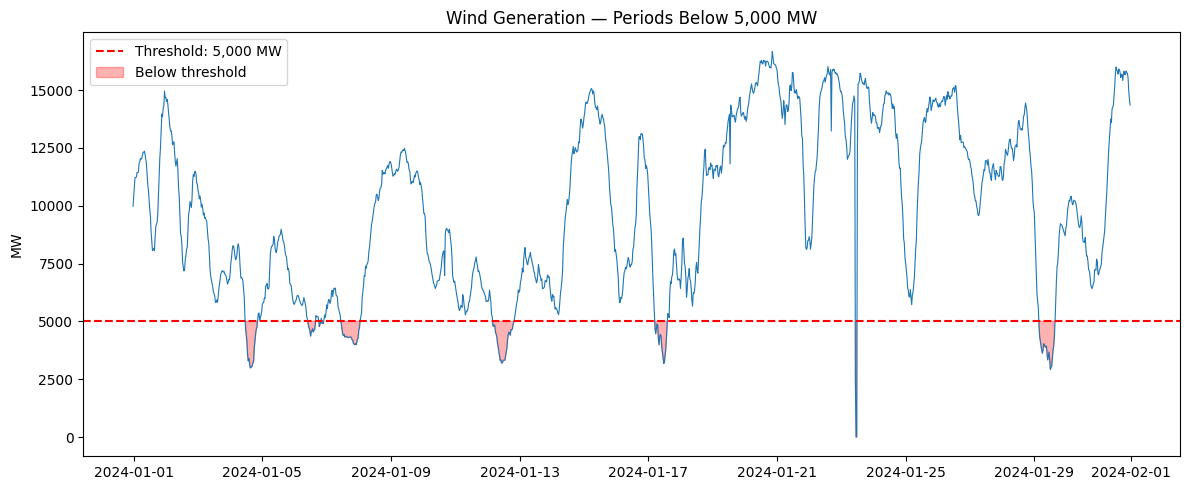

In [8]:
# Visualise: show the time series with a threshold line
threshold = 5000  # change this to explore

plt.plot(actuals['startTime'], actuals['generation'], linewidth=0.8)
plt.axhline(threshold, color='red', linestyle='--', label=f'Threshold: {threshold:,} MW')
plt.fill_between(actuals['startTime'], actuals['generation'], threshold,
                 where=actuals['generation'] < threshold,
                 color='red', alpha=0.3, label='Below threshold')
plt.ylabel('MW')
plt.title(f'Wind Generation — Periods Below {threshold:,} MW')
plt.legend()
plt.tight_layout()
plt.show()

---

## 5. Question 3 — Does Time of Day Affect Reliability?

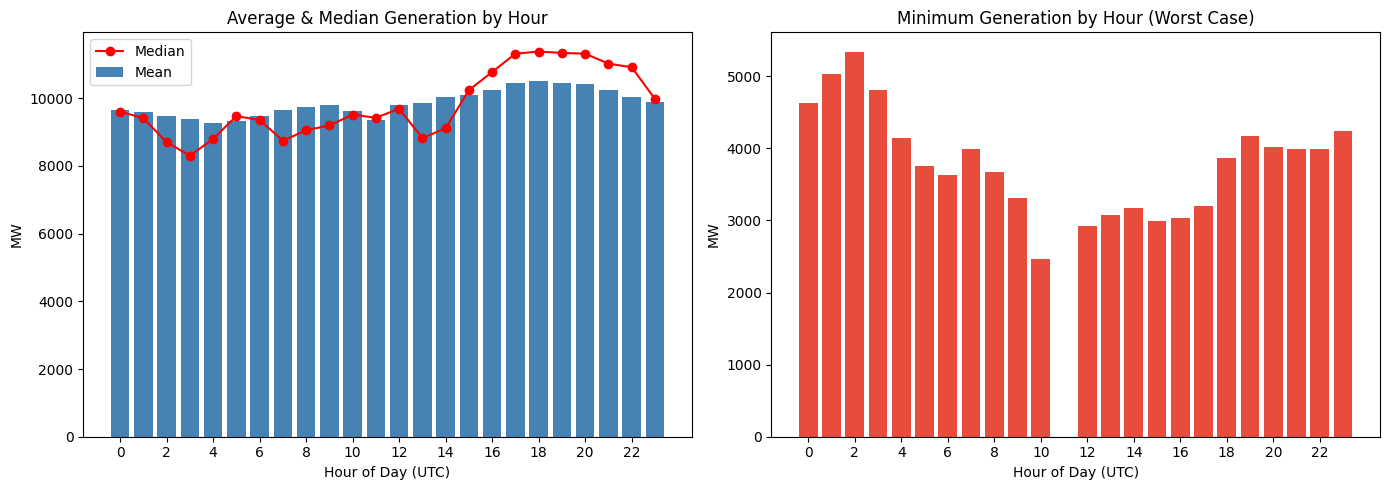

In [9]:
actuals['hour'] = actuals['startTime'].dt.hour

hourly = actuals.groupby('hour')['generation'].agg(['mean', 'median', 'min'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(hourly.index, hourly['mean'], color='steelblue', label='Mean')
axes[0].plot(hourly.index, hourly['median'], 'ro-', label='Median')
axes[0].set_xlabel('Hour of Day (UTC)')
axes[0].set_ylabel('MW')
axes[0].set_title('Average & Median Generation by Hour')
axes[0].set_xticks(range(0, 24, 2))
axes[0].legend()

axes[1].bar(hourly.index, hourly['min'], color='#e74c3c')
axes[1].set_xlabel('Hour of Day (UTC)')
axes[1].set_ylabel('MW')
axes[1].set_title('Minimum Generation by Hour (Worst Case)')
axes[1].set_xticks(range(0, 24, 2))

plt.tight_layout()
plt.show()

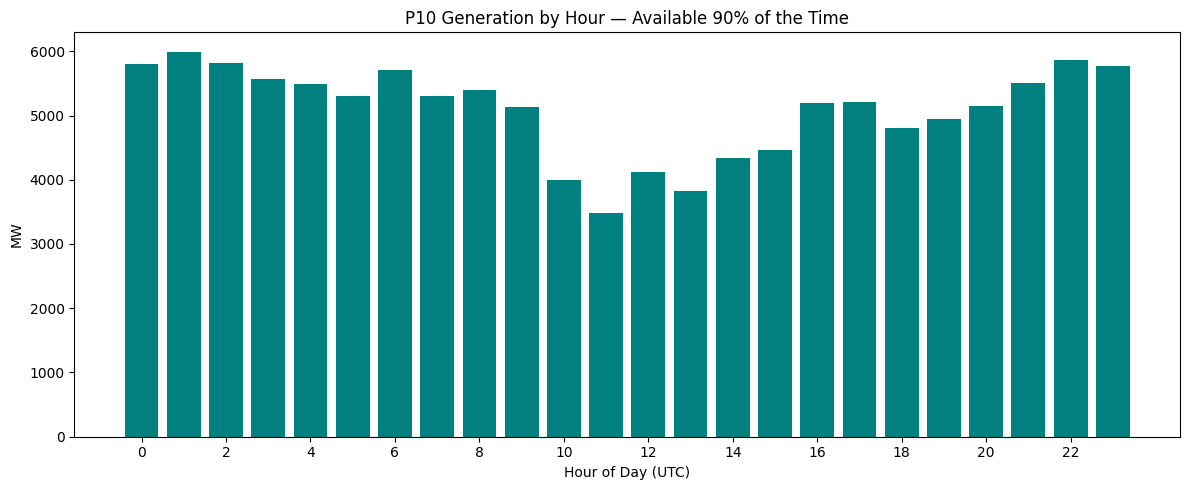

Lowest P10 hour:  11:00 — 3,476 MW
Highest P10 hour: 01:00 — 5,995 MW


In [10]:
# P10 by hour — what can we count on 90% of the time, per hour?
hourly_p10 = actuals.groupby('hour')['generation'].quantile(0.10)

plt.bar(hourly_p10.index, hourly_p10.values, color='teal')
plt.xlabel('Hour of Day (UTC)')
plt.ylabel('MW')
plt.title('P10 Generation by Hour — Available 90% of the Time')
plt.xticks(range(0, 24, 2))
plt.tight_layout()
plt.show()

print(f'Lowest P10 hour:  {hourly_p10.idxmin():02d}:00 — {hourly_p10.min():,.0f} MW')
print(f'Highest P10 hour: {hourly_p10.idxmax():02d}:00 — {hourly_p10.max():,.0f} MW')

---

## 6. Question 4 — Worst-Case Stretch in January

In [11]:
# Rolling 24-hour minimum — what's the worst 24-hour window?
actuals['rolling_24h_min'] = actuals['generation'].rolling(window=48, min_periods=48).min()  # 48 slots = 24h

worst_24h = actuals.loc[actuals['rolling_24h_min'].idxmin()]
print(f'Worst 24-hour window ended at: {worst_24h["startTime"]}')
print(f'Minimum generation in that window: {worst_24h["rolling_24h_min"]:,.0f} MW')

# Also: what was the absolute lowest generation?
non_zero = actuals[actuals['generation'] > 0]
lowest = non_zero.loc[non_zero['generation'].idxmin()]
print(f'\nAbsolute lowest (non-zero): {lowest["generation"]:,} MW at {lowest["startTime"]}')

Worst 24-hour window ended at: 2024-01-23 11:00:00+00:00
Minimum generation in that window: 0 MW

Absolute lowest (non-zero): 2,469 MW at 2024-01-23 10:30:00+00:00


In [12]:
# Zoom into the worst week
# Find the day with lowest average generation
actuals['date'] = actuals['startTime'].dt.date
daily_avg = actuals.groupby('date')['generation'].mean().sort_values()

print('Lowest daily averages:')
for date, avg in daily_avg.head(5).items():
    print(f'  {date}  avg: {avg:,.0f} MW')

Lowest daily averages:
  2024-01-12  avg: 4,653 MW
  2024-01-07  avg: 5,025 MW
  2024-01-06  avg: 5,275 MW
  2024-01-04  avg: 5,725 MW
  2024-01-29  avg: 5,839 MW


---

## 7. Summary & Observations

In [13]:
# --- Summary Table: Percentile, Availability, Drought Risk ---

def find_drought_durations(series, threshold):
    below = (series < threshold).values
    durations, count = [], 0
    for val in below:
        if val: count += 1
        else:
            if count > 0: durations.append(count * 0.5)
            count = 0
    if count > 0: durations.append(count * 0.5)
    return durations

rows = []
for p in [1, 5, 10, 25, 50]:
    mw = actuals['generation'].quantile(p / 100)
    avail = 100 - p
    droughts = find_drought_durations(actuals['generation'], mw)
    n_droughts = len(droughts)
    longest = f'{max(droughts):.1f}h' if droughts else '—'
    total_hrs = f'{sum(droughts):.0f}h' if droughts else '—'
    rows.append({
        'Percentile': f'P{p}',
        'MW Threshold': f'{mw:,.0f}',
        'Availability': f'{avail}%',
        'Drought Events': n_droughts,
        'Longest Drought': longest,
        'Total Hrs Below': total_hrs
    })

summary = pd.DataFrame(rows)
print('Wind Reliability Summary — January 2024')
print('=' * 75)
print(summary.to_string(index=False))
print()
print(f'Mean generation: {actuals["generation"].mean():,.0f} MW')
print(f'Capacity factor (assuming 30 GW installed): {actuals["generation"].mean()/30000*100:.1f}%')
print(f'Max half-hour ramp: +{actuals["generation"].diff().max():,.0f} / {actuals["generation"].diff().min():,.0f} MW')

Wind Reliability Summary — January 2024
Percentile MW Threshold Availability  Drought Events Longest Drought Total Hrs Below
        P1        3,234          99%               5            3.0h              8h
        P5        4,301          95%               8           10.5h             38h
       P10        5,089          90%              10           16.5h             74h
       P25        6,733          75%              21           55.5h            186h
       P50        9,883          50%              12          127.5h            372h

Mean generation: 9,849 MW
Capacity factor (assuming 30 GW installed): 32.8%
Max half-hour ramp: +12,439 / -12,083 MW


### Observations

**1. Wind is highly variable but rarely near zero.**  
Generation ranged from 0 to 16,662 MW (mean ~9,849, std ~3,675). The coefficient of variation is ~37%, confirming that wind output on any given half-hour is inherently unpredictable.

**2. The "firm" capacity of wind is very low relative to installed capacity.**  
At the P5 level, generation exceeded ~4,301 MW 95% of the time; at P10, ~5,089 MW 90% of the time. If a grid planner needs to guarantee capacity, they can only count on ~4,300–5,000 MW with 90–95% confidence — roughly 14–17% of the assumed 30 GW installed capacity.

**3. Low-wind droughts can be prolonged and operationally significant.**  
Below 5,000 MW the longest drought lasted 16 hours. Below 7,000 MW it extended to 56.5 hours (~2.4 days), and below 8,000 MW it reached 62.5 hours. A 2+ day stretch of sub-average wind demands serious dispatchable backup or storage.

**4. Daytime (especially midday) is less reliable than nighttime.**  
P10 generation at night (22:00–05:00) is ~5,300–5,900 MW, while midday hours (10:00–13:00) drop to ~3,400–4,100 MW. This is counterintuitive but important: peak electricity demand is during the day, exactly when wind reliability is lowest.

**5. The worst-case scenario is severe.**  
The worst 24-hour window (around Jan 23) contained a reading of 0 MW (likely a data artifact); the lowest non-zero value was 2,469 MW. Seven days in January averaged below 7,000 MW. These tail events define the backup capacity a grid must maintain.

**6. Ramp rates can be extreme.**  
Half-hourly swings reached +12,439 / −12,083 MW. The average absolute ramp is ~249 MW per 30 minutes, but the tails are dramatic and require fast-response balancing capacity.

### Recommendation

Based on January 2024 data, a grid planner should **count on approximately 4,000–5,000 MW of firm wind capacity** (the P5–P10 range). This represents only ~14–17% of the ~30 GW installed base. The remaining demand must be met by dispatchable generation (gas, hydro, nuclear) or storage, especially during prolonged low-wind periods that can last 2+ days.

The capacity factor for the month was ~32.8%, meaning wind delivered roughly a third of its rated capacity on average — but the distribution is wide and the minimum is near zero. Planning around the average would be reckless; planning around the P5/P10 level provides a reasonable margin while still crediting wind for its contribution.

**Key caveat:** This analysis covers a single winter month. A full recommendation would require at least 12 months of data to account for seasonal variation (summer wind is typically lower in the UK).